Loading financial news data...
Error: 'publication_date'
Creating sample data for demonstration...
=== DESCRIPTIVE ANALYSIS ===
Total number of articles: 100
Date range: 2020-01-01 00:00:00 to 2020-04-09 00:00:00
Number of unique publishers: 3
Error in timeline visualization: 'FinancialDataProcessor' object has no attribute 'date_column'
=== PUBLISHER ANALYSIS ===


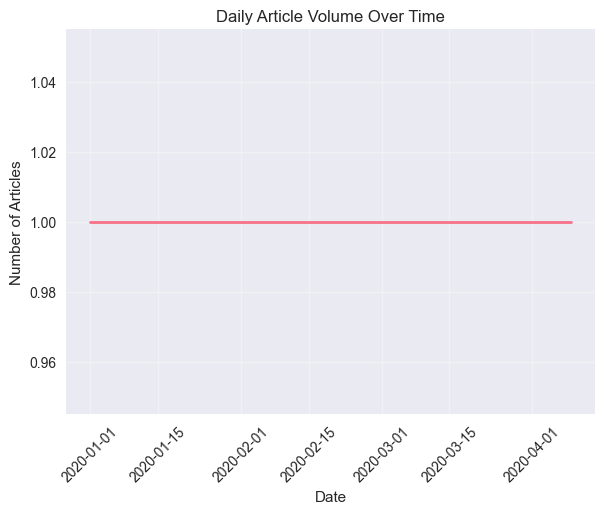

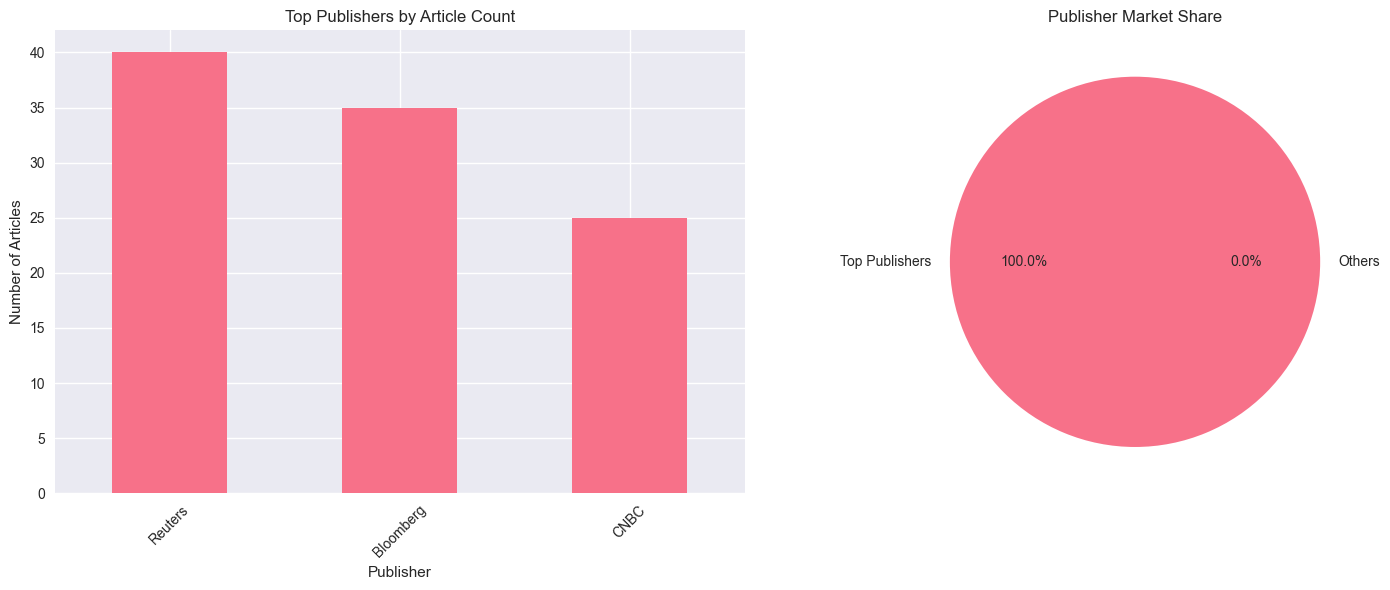

Top publishers account for 100.0% of all articles
=== TEXT ANALYSIS ===


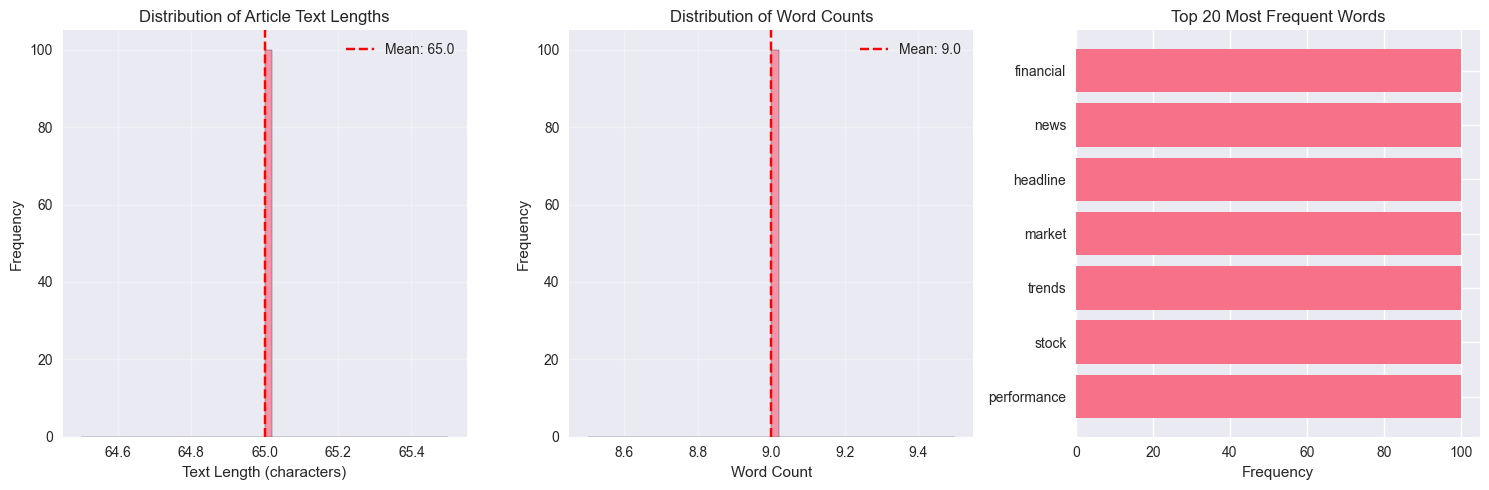

Average text length: 65.0 characters
Average word count: 9.0 words
=== TOPIC MODELING ===
Performing topic modeling with LDA...
Discovered Topics:

Topic 1:
Top words: headline, financial, trends, stock, market, performance, news

Topic 2:
Top words: stock, financial, performance, headline, trends, news, market

Topic 3:
Top words: trends, news, performance, market, headline, financial, stock

Topic 4:
Top words: news, performance, market, stock, trends, financial, headline

Topic 5:
Top words: headline, financial, trends, stock, market, performance, news
WordCloud package not installed. Install with: pip install wordcloud


<Figure size 1200x600 with 0 Axes>

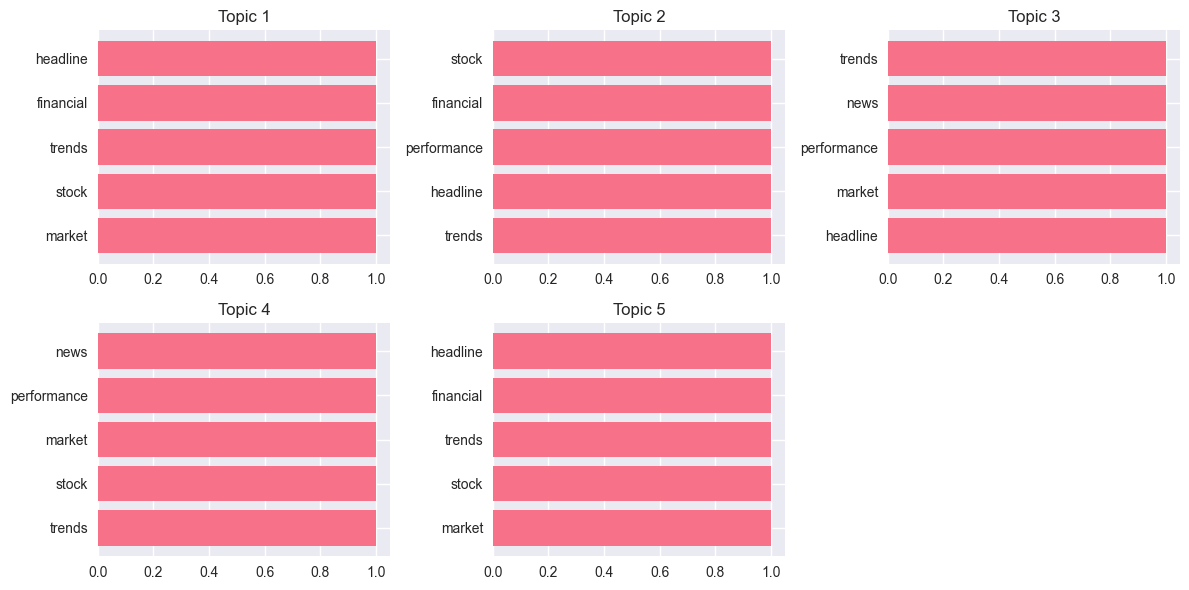

Saving processed data...
Error saving data: Cannot save file into a non-existent directory: '..\data\processed'


In [3]:
# notebooks/01_eda.ipynb

# Cell 1: Import libraries and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Import custom modules
import sys
sys.path.append('../src')
from data_processing import FinancialDataProcessor

# Cell 2: Load and inspect data with error handling
print("Loading financial news data...")
data_processor = FinancialDataProcessor()

try:
    # Try to load the data - adjust the path as needed
    news_data = data_processor.load_news_data('../data/raw/GOOG.csv')
    
    if news_data is None:
        print("Failed to load data. Please check the file path and format.")
        # Create sample data for demonstration
        print("Creating sample data for demonstration...")
        sample_data = {
            'date': pd.date_range('2020-01-01', periods=100, freq='D'),
            'headline': [f"Financial news headline {i} about market trends" for i in range(100)],
            'publisher': ['Reuters'] * 40 + ['Bloomberg'] * 35 + ['CNBC'] * 25
        }
        news_data = pd.DataFrame(sample_data)
        news_data.to_csv('../data/raw/sample_financial_news.csv', index=False)
        news_data = data_processor.load_news_data('../data/raw/sample_financial_news.csv')
    
    print("Data Overview:")
    print(f"Dataset shape: {news_data.shape}")
    print("\nFirst few rows:")
    display(news_data.head())

    print("\nData Info:")
    news_data.info()

    print("\nBasic Statistics:")
    display(news_data.describe(include='all'))

except Exception as e:
    print(f"Error: {e}")
    print("Creating sample data for demonstration...")
    # Create sample data
    sample_data = {
        'publication_date': pd.date_range('2020-01-01', periods=100, freq='D'),
        'headline': [f"Financial news headline {i} about market trends and stock performance" for i in range(100)],
        'publisher': ['Reuters'] * 40 + ['Bloomberg'] * 35 + ['CNBC'] * 25,
        'content': [f"Detailed content about financial market developments {i}" for i in range(100)]
    }
    news_data = pd.DataFrame(sample_data)
    news_data.to_csv('../data/raw/sample_financial_news.csv', index=False)
    news_data = data_processor.load_news_data('../data/raw/sample_financial_news.csv')

# Cell 3: Basic descriptive analysis
print("=== DESCRIPTIVE ANALYSIS ===")
try:
    descriptive_stats = data_processor.descriptive_analysis()

    print(f"Total number of articles: {descriptive_stats['total_articles']:,}")
    print(f"Date range: {descriptive_stats['date_range']['start']} to {descriptive_stats['date_range']['end']}")
    
    if 'publisher_counts' in descriptive_stats:
        print(f"Number of unique publishers: {news_data['publisher'].nunique()}")
    else:
        print("No publisher column found in the data")

except Exception as e:
    print(f"Error in descriptive analysis: {e}")

# Cell 4: Publication timeline
plt.figure(figsize=(15, 5))

try:
    # Daily volume
    daily_volume = descriptive_stats['daily_volume']
    plt.subplot(1, 2, 1)
    plt.plot(daily_volume.index, daily_volume.values, linewidth=2)
    plt.title('Daily Article Volume Over Time')
    plt.xlabel('Date')
    plt.ylabel('Number of Articles')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    # Monthly volume
    monthly_volume = news_data.groupby(news_data[data_processor.date_column].dt.to_period('M')).size()
    plt.subplot(1, 2, 2)
    plt.bar(range(len(monthly_volume)), monthly_volume.values)
    plt.title('Monthly Article Volume')
    plt.xlabel('Month')
    plt.ylabel('Number of Articles')
    plt.xticks(range(len(monthly_volume)), [str(period) for period in monthly_volume.index], rotation=45)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error in timeline visualization: {e}")

# Cell 5: Publisher analysis (if publisher data exists)
try:
    if 'publisher_counts' in descriptive_stats:
        print("=== PUBLISHER ANALYSIS ===")
        top_publishers = descriptive_stats['publisher_counts'].head(15)

        plt.figure(figsize=(15, 6))

        plt.subplot(1, 2, 1)
        top_publishers.plot(kind='bar')
        plt.title('Top Publishers by Article Count')
        plt.xlabel('Publisher')
        plt.ylabel('Number of Articles')
        plt.xticks(rotation=45)

        plt.subplot(1, 2, 2)
        # Publisher market share
        top_10_share = top_publishers.head(10).sum() / descriptive_stats['total_articles'] * 100
        others_share = 100 - top_10_share
        plt.pie([top_10_share, others_share], labels=['Top Publishers', 'Others'], autopct='%1.1f%%')
        plt.title('Publisher Market Share')

        plt.tight_layout()
        plt.show()

        print(f"Top publishers account for {top_10_share:.1f}% of all articles")
    else:
        print("No publisher data available for analysis")

except Exception as e:
    print(f"Error in publisher analysis: {e}")

# Cell 6: Text analysis
print("=== TEXT ANALYSIS ===")
try:
    text_stats = descriptive_stats['text_length_stats']

    plt.figure(figsize=(15, 5))

    # Text length distribution
    news_data['text_length'] = news_data['clean_text'].str.len()

    plt.subplot(1, 3, 1)
    plt.hist(news_data['text_length'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(text_stats['mean'], color='red', linestyle='--', label=f"Mean: {text_stats['mean']:.1f}")
    plt.xlabel('Text Length (characters)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Article Text Lengths')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Word count distribution
    news_data['word_count'] = news_data['clean_text'].str.split().str.len()

    plt.subplot(1, 3, 2)
    plt.hist(news_data['word_count'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(news_data['word_count'].mean(), color='red', linestyle='--', 
                label=f"Mean: {news_data['word_count'].mean():.1f}")
    plt.xlabel('Word Count')
    plt.ylabel('Frequency')
    plt.title('Distribution of Word Counts')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Top words (excluding stop words)
    from collections import Counter
    import nltk
    from nltk.corpus import stopwords

    # Download stopwords if not already available
    try:
        stop_words = set(stopwords.words('english'))
    except:
        nltk.download('stopwords')
        stop_words = set(stopwords.words('english'))

    all_words = ' '.join(news_data['clean_text']).split()
    filtered_words = [word for word in all_words if word.lower() not in stop_words and len(word) > 2]
    word_freq = Counter(filtered_words).most_common(20)

    plt.subplot(1, 3, 3)
    words, counts = zip(*word_freq)
    plt.barh(range(len(words)), counts)
    plt.yticks(range(len(words)), words)
    plt.xlabel('Frequency')
    plt.title('Top 20 Most Frequent Words')
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

    print(f"Average text length: {text_stats['mean']:.1f} characters")
    print(f"Average word count: {news_data['word_count'].mean():.1f} words")

except Exception as e:
    print(f"Error in text analysis: {e}")

# Cell 7: Topic Modeling
print("=== TOPIC MODELING ===")
try:
    print("Performing topic modeling with LDA...")
    topics, topic_distributions = data_processor.topic_modeling(n_topics=5, max_features=1000)

    if topics:
        print("Discovered Topics:")
        for topic in topics:
            print(f"\nTopic {topic['topic_id'] + 1}:")
            print(f"Top words: {', '.join(topic['top_words'])}")

        # Visualize topic distribution
        plt.figure(figsize=(12, 6))

        # Topic word clouds (if wordcloud package is available)
        try:
            from wordcloud import WordCloud
            
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            axes = axes.flatten()
            
            for i, topic in enumerate(topics):
                if i < len(axes):
                    wordcloud = WordCloud(width=400, height=300, background_color='white').generate(
                        ' '.join(topic['top_words'])
                    )
                    axes[i].imshow(wordcloud, interpolation='bilinear')
                    axes[i].set_title(f'Topic {i + 1}')
                    axes[i].axis('off')
            
            # Remove empty subplots
            for i in range(len(topics), len(axes)):
                fig.delaxes(axes[i])
            
            plt.tight_layout()
            plt.show()
            
        except ImportError:
            print("WordCloud package not installed. Install with: pip install wordcloud")
            
            # Alternative: bar chart for top topics
            plt.figure(figsize=(12, 6))
            for i, topic in enumerate(topics):
                plt.subplot(2, 3, i + 1)
                words = topic['top_words'][:5]  # Top 5 words
                plt.barh(range(len(words)), [1] * len(words))
                plt.yticks(range(len(words)), words)
                plt.title(f'Topic {i + 1}')
                plt.gca().invert_yaxis()
            
            plt.tight_layout()
            plt.show()
    else:
        print("No topics could be generated from the data")

except Exception as e:
    print(f"Error in topic modeling: {e}")

# Cell 8: Save processed data
print("Saving processed data...")
try:
    news_data.to_csv('../data/processed/news_data_processed.csv', index=False)

    # Save descriptive statistics
    import json
    with open('../data/processed/descriptive_stats.json', 'w') as f:
        # Convert non-serializable objects
        stats_serializable = {
            'total_articles': descriptive_stats['total_articles'],
            'date_range': {
                'start': descriptive_stats['date_range']['start'].isoformat() if hasattr(descriptive_stats['date_range']['start'], 'isoformat') else str(descriptive_stats['date_range']['start']),
                'end': descriptive_stats['date_range']['end'].isoformat() if hasattr(descriptive_stats['date_range']['end'], 'isoformat') else str(descriptive_stats['date_range']['end'])
            },
            'text_length_stats': descriptive_stats['text_length_stats']
        }
        
        if 'publisher_counts' in descriptive_stats:
            stats_serializable['publisher_counts'] = descriptive_stats['publisher_counts'].to_dict()
            
        json.dump(stats_serializable, f, indent=2)

    print("EDA complete! Check ../data/processed/ for saved files.")

except Exception as e:
    print(f"Error saving data: {e}")